In [2]:
# ─────────────────────────────────────────────
# Notebook 04 - ML Modeling
# Goal: Train a model to predict hospital 
# uncompensated care costs
# We'll use Random Forest — it handles:
# - Mixed feature types (numbers + categories)
# - Non-linear relationships
# - Feature importance out of the box
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import os

os.makedirs('../outputs', exist_ok=True)

df = pd.read_csv('../data/modeling_data.csv')
print(df.shape)
print(df['year'].value_counts().sort_index())


(22745, 30)
year
2019    4638
2020    4529
2021    4557
2022    4515
2023    4506
Name: count, dtype: int64


In [3]:
# ─────────────────────────────────────────────
# Step 1 - Define Features and Target
# We select features that are:
# 1. Actually available before we'd want to 
#    make a prediction (no data leakage)
# 2. Meaningful predictors based on EDA
# We EXCLUDE Cost of Charity Care and Total Bad 
# Debt Expense — they're components OF 
# uncompensated care, using them would be 
# cheating (data leakage)
# ─────────────────────────────────────────────

# These are our input features for the model
feature_cols = [
    'Number of Beds',
    'FTE - Employees on Payroll',
    'Total Days Title XVIII',        # Medicare days
    'Total Days Title XIX',          # Medicaid days
    'Total Discharges (V + XVIII + XIX + Unknown)',
    'Total Patient Revenue',
    'Net Patient Revenue',
    'Net Income',
    'Net Revenue from Medicaid',
    'Total Assets',
    'Total Liabilities',
    'Total Costs',
    'Disproportionate Share Adjustment',
    'Type of Control',
    'Provider Type',
    'Is_Urban',                      # our engineered feature
    'Uncompensated_Care_Per_Bed',    # our engineered feature
    'year'
]

# Target is the log-transformed uncompensated care
# We train on log values, reverse to dollars at evaluation
X = df[feature_cols]
y = df['log_uncompensated_care']

# Split 80% training, 20% testing
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 18196
Testing samples:  4549
Number of features: 18


In [4]:
# ─────────────────────────────────────────────
# Step 3 - Train and Compare 3 Models
# Linear Regression = simple baseline
# Random Forest = handles non-linear patterns
# XGBoost = often best performance, gradient 
#            boosting builds trees sequentially
#            each tree corrects the last one's 
#            errors
# We compare all three to pick the best one
# ─────────────────────────────────────────────

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, max_depth=15, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=42, n_jobs=-1, verbosity=0
    )
}

results = {}

for name, mdl in models.items():
    print(f"Training {name}...")
    mdl.fit(X_train, y_train)
    
    y_pred_log = mdl.predict(X_test)
    y_pred_dollars = np.expm1(y_pred_log)
    y_test_dollars = np.expm1(y_test)
    
    r2 = r2_score(y_test, y_pred_log)
    mae = mean_absolute_error(y_test_dollars, y_pred_dollars)
    
    results[name] = {'R2': r2, 'MAE': mae}
    print(f"  R²: {r2:.4f} | MAE: ${mae:,.0f}")

print("\nDone!")

Training Linear Regression...
  R²: 0.4871 | MAE: $5,135,343,963
Training Random Forest...
  R²: 0.9977 | MAE: $362,077
Training XGBoost...
  R²: 0.9932 | MAE: $503,575

Done!


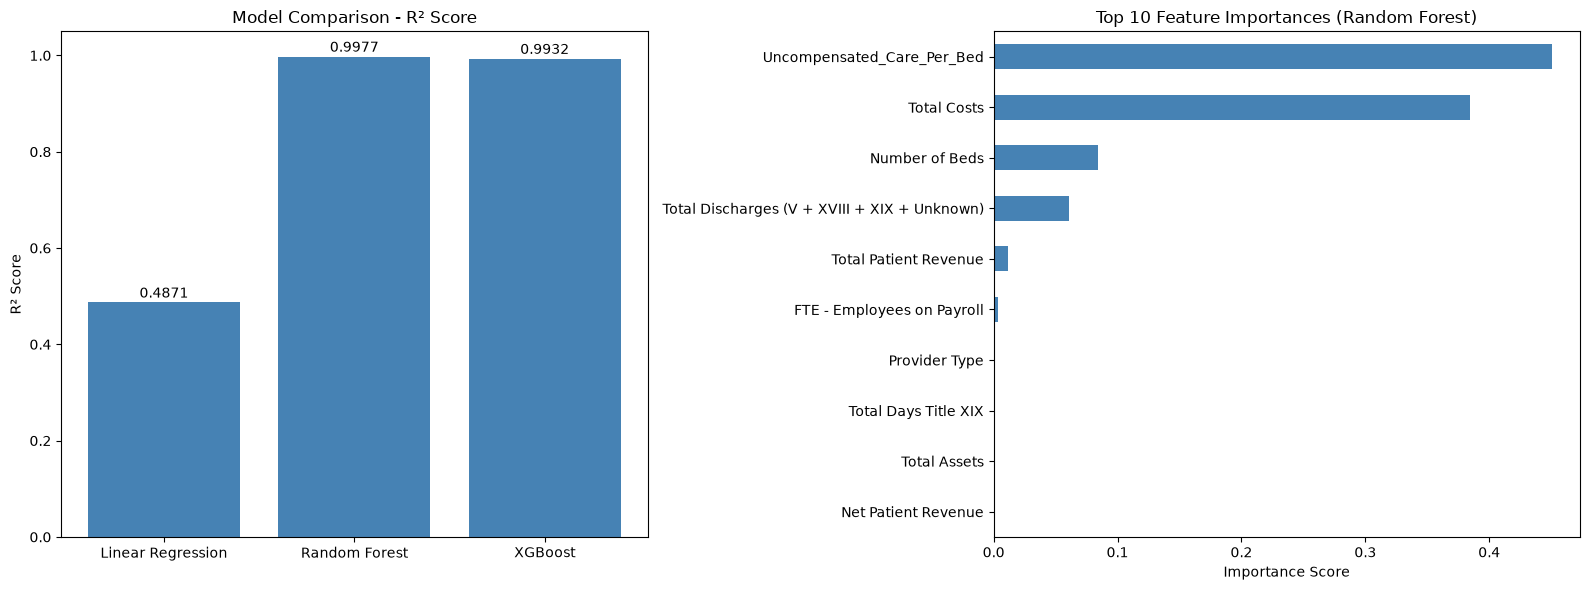

In [5]:
# ─────────────────────────────────────────────
# Step 4 - Visualize Model Comparison + 
# Feature Importance
# Two plots:
# 1. R² comparison across all 3 models
# 2. Which features mattered most to 
#    Random Forest (our winning model)
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - R² comparison
model_names = list(results.keys())
r2_scores = [results[m]['R2'] for m in model_names]

axes[0].bar(model_names, r2_scores, color='steelblue', edgecolor='none')
axes[0].set_title('Model Comparison - R² Score')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.05)

# Add value labels on bars
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

# Plot 2 - Feature importance from Random Forest
feature_importance = pd.Series(
    models['Random Forest'].feature_importances_,
    index=feature_cols
).sort_values(ascending=False).head(10)

feature_importance.plot(kind='barh', ax=axes[1], 
                        color='steelblue', edgecolor='none')
axes[1].set_title('Top 10 Feature Importances (Random Forest)')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/06_model_results.png', dpi=150)
plt.show()

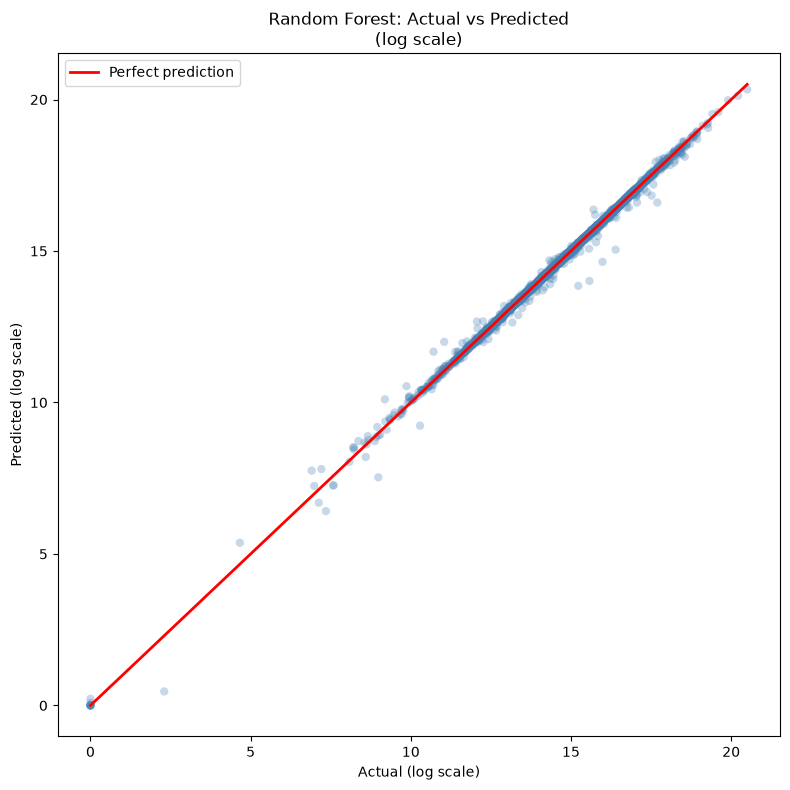

In [6]:
# ─────────────────────────────────────────────
# Step 5 - Actual vs Predicted Plot
# This is the classic ML evaluation visual
# Perfect model = all dots on the diagonal line
# Spread around the line = prediction error
# We plot in log scale for readability
# ─────────────────────────────────────────────

y_pred_log = models['Random Forest'].predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_log, alpha=0.3, color='steelblue', edgecolor='none')

# Perfect prediction line
min_val = min(y_test.min(), y_pred_log.min())
max_val = max(y_test.max(), y_pred_log.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         color='red', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual (log scale)')
plt.ylabel('Predicted (log scale)')
plt.title('Random Forest: Actual vs Predicted\n(log scale)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/07_actual_vs_predicted.png', dpi=150)
plt.show()

In [8]:
import joblib

# Save the trained Random Forest model to disk
# joblib is the standard way to save sklearn models
joblib.dump(models['Random Forest'], '../model/random_forest_model.pkl')
print("Model saved!")

Model saved!
